Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Load Dataset

In [3]:
df = pd.read_csv("customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

Exploratory Data Analysis

In [6]:
df.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [8]:
df['Ticket Type'].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


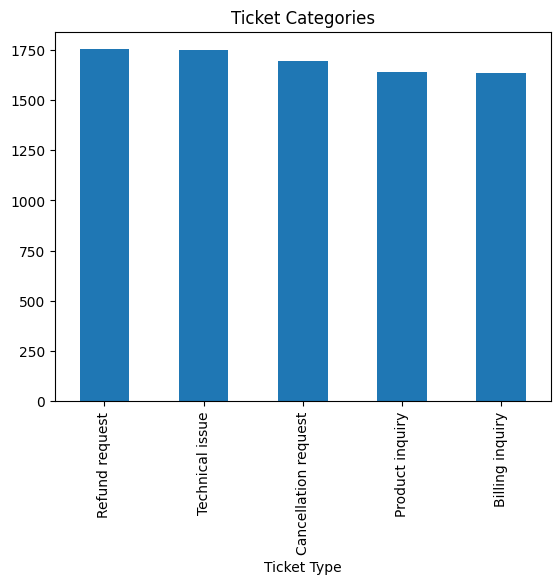

In [9]:
import matplotlib.pyplot as plt

df['Ticket Type'].value_counts().plot(kind='bar')
plt.title("Ticket Categories")
plt.show()

Text Cleaning

In [31]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [11]:
df['clean_text'] = df['Ticket Description'].apply(clean_text)

df[['Ticket Description', 'clean_text']].head()

,Ticket Description,clean_text
0,I'm having an issue with the {product_purchase...,im issue productpurchased please assistyour bi...
1,I'm having an issue with the {product_purchase...,im issue productpurchased please assistif need...
2,I'm facing a problem with my {product_purchase...,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,im issue productpurchased please assistif prob...
4,I'm having an issue with the {product_purchase...,im issue productpurchased please assistnote se...


TF-IDF Feature Extraction

In [13]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

y = df['Ticket Type']

Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Classification Model

In [15]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [16]:
y_pred = model.predict(X_test)

Evaluate Model

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.18772136953955135


In [18]:
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.15      0.06      0.08       357
Cancellation request       0.19      0.20      0.20       327
     Product inquiry       0.18      0.16      0.17       316
      Refund request       0.17      0.24      0.20       345
     Technical issue       0.21      0.29      0.24       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.18      1694
        weighted avg       0.18      0.19      0.18      1694



Priority Assignment Logic

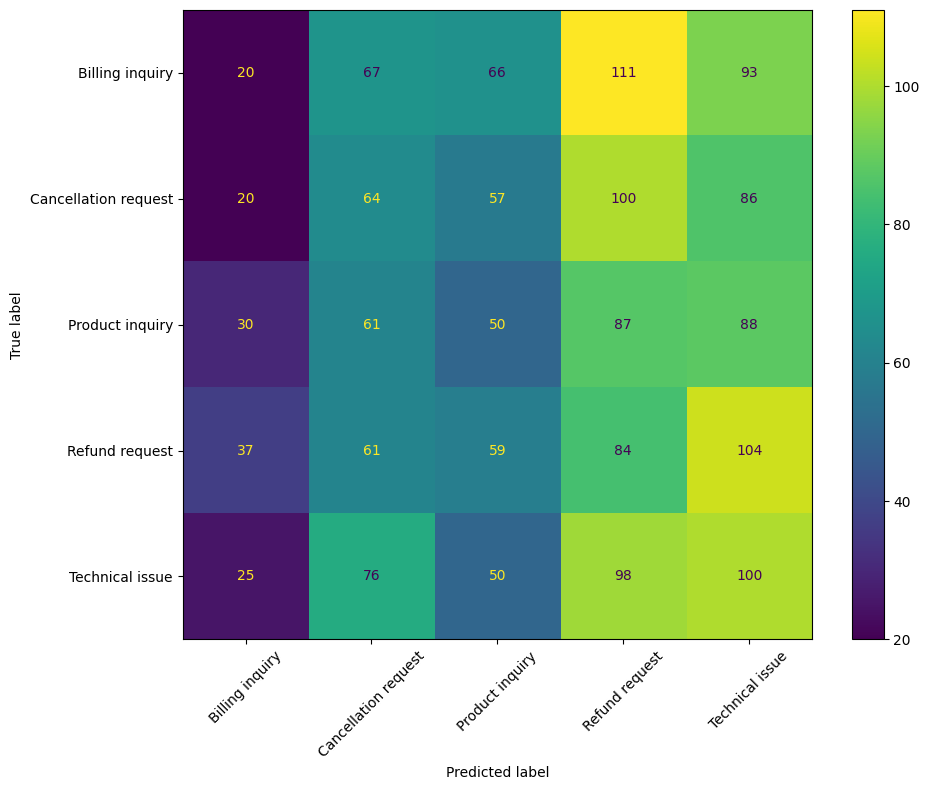

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    ax=ax
)

plt.tight_layout()
plt.show()

In [20]:
high_keywords = [
    'urgent',
    'failed',
    'error',
    'crash',
    'down'
]

medium_keywords = [
    'slow',
    'issue',
    'problem'
]

In [32]:
def assign_priority(text):

    text = str(text).lower()

    if any(word in text for word in high_keywords):
        return "High"

    elif any(word in text for word in medium_keywords):
        return "Medium"

    else:
        return "Low"

In [22]:
df['Priority'] = df['Ticket Description'].apply(assign_priority)

df[['Ticket Description', 'Priority']].head()

,Ticket Description,Priority
0,I'm having an issue with the {product_purchase...,Medium
1,I'm having an issue with the {product_purchase...,Medium
2,I'm facing a problem with my {product_purchase...,Medium
3,I'm having an issue with the {product_purchase...,Medium
4,I'm having an issue with the {product_purchase...,Medium


Test on New Ticket

In [23]:
sample = [
    "My payment failed and account is blocked"
]

sample_clean = [clean_text(text) for text in sample]

sample_vector = tfidf.transform(sample_clean)

prediction = model.predict(sample_vector)

print("Category:", prediction[0])

print(
    "Priority:",
    assign_priority(sample[0])
)

Category: Technical issue
Priority: High


In [24]:
y_priority = df['Ticket Priority']

In [25]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42
)

In [26]:
priority_model = MultinomialNB()

priority_model.fit(X_train_p, y_train_p)

MultinomialNB()

In [27]:
priority_pred = priority_model.predict(X_test_p)

In [28]:
print("Priority Accuracy:")
print(accuracy_score(y_test_p, priority_pred))

Priority Accuracy:
0.25737898465171194


In [29]:
print(classification_report(y_test_p, priority_pred))

              precision    recall  f1-score   support

    Critical       0.24      0.27      0.25       411
        High       0.25      0.27      0.26       409
         Low       0.25      0.17      0.21       415
      Medium       0.29      0.32      0.30       459

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.25      1694
weighted avg       0.26      0.26      0.25      1694



In [30]:
sample = ["My payment failed and I cannot access my account"]

sample_clean = [clean_text(text) for text in sample]

sample_vector = tfidf.transform(sample_clean)

category_prediction = model.predict(sample_vector)

priority_prediction = priority_model.predict(sample_vector)

print("Ticket:", sample[0])
print("Predicted Category:", category_prediction[0])
print("Predicted Priority:", priority_prediction[0])

Ticket: My payment failed and I cannot access my account
Predicted Category: Product inquiry
Predicted Priority: High


Conclusion Section

This project automatically classifies customer support tickets into categories using NLP and Machine Learning.

TF-IDF was used to convert text into numerical features.

A Multinomial Naive Bayes classifier was trained to predict ticket categories.

Priority levels (High, Medium, Low) were assigned using business rules based on ticket content.

This system helps support teams reduce manual sorting effort and respond faster to critical issues.